# Multiobjective optimization --  3 cost terms

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/23 20:15:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2025-11-23 20:15:14,696 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/11/23 20:15:15 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-11-23 20:15:16,290 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-11-23 20:15:18,020 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-11-23 20:15:18,021 INFO     >>> Reading claims file: /Users/Charles/DATA/ckd/ckd_claims
2025-11-23 20:15:18,921 INFO     >>> CLAIMS has 253,070,875 rows                
2025-11-23 20:15:25,996 INFO     >

# Load Data

In [3]:
df_2018 = spark.read.format("parquet").load( "0917_2017_18_with_2017_cost.parquet")
df_og = df_2018.toPandas()
df_og.shape,df_og.columns

((33542, 95),
 Index(['ENROLID', 'annual_cost_2017', 'highcost_gt_50000_2017',
        'highcost_gt_75000_2017', 'highcost_gt_100000_2017',
        'highcost_gt_200000_2017', 'highcost_gt_300000_2017',
        'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'INCOME_LEVEL',
        'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000',
        'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000',
        'highcost_gt_400000', 'highcost_gt_500000', 'AGEGRP', 'SEX', 'REGION',
        'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia',
        'has_Hyperlipidemia', 'has_Acute_Kidney_Failure',
        'has_Hyperparathyroidism', 'has_Kidney_Transplant',
        'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy',
        'has_Hypothyroidism', 'has_Sleep_Apnea', 'stage_2017', 'util_2017',
        'Antihyperlipidemic Drugs, NEC (THRCLS_53)',
        'Cardiac, Beta Blockers (THRCLS_51)',
        'Cardiac, Calcium Channel (THRCLS_52)',
        'Psychot

# Feature groups, define high cost and train-test-split

In [4]:
import importlib
import model_pipeline
importlib.reload(model_pipeline)
BIN_FLAG_COLUMNS = model_pipeline.get_bin_flag_columns(df_og) +['lab_monitoring_adherent','nephrology_consult_adherent','early_nephrology_referral']
STAGE_COLUMNS = [col for col in df_og.columns if "stage" in col.lower()]
#["stage_2017",'2017Q1_max_ckd_stage','2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage','2017Q4_max_ckd_stage']
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = model_pipeline.get_true_num_columns(df_og,CAT_COLUMNS)+[ 'util_2017', 'total_increasing_quarters_2017'
, 'total_lab_tests', 'ckd_visit_count', 'quarters_with_labs', 'nephrology_visit_count', 'days_to_nephrology','MEDIAN_INCOME']
COST_COLUMNS = [col for col in df_og.columns if 
            "cost" in col.lower() or 
             "quarterly" in col.lower()  or "increasing" in col.lower()
             ]
UTILIZATION_COLUMNS = [col for col in df_og.columns if "claims" not in col.lower() ] + ['util_2017']
print("categorical cols: ", CAT_COLUMNS)
print("stage cols: ", STAGE_COLUMNS)
print(COST_COLUMNS)
leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

def make_cost_stratum_3class(df):
    # Default to low-cost (class 0)
    cost_stratum = pd.Series(0, index=df.index)
    # Moderate (class 1): 50k+ to 100k
   # cost_stratum[(df['annual_cost_2017'] <= 10000)] = 1
   # cost_stratum[(df['annual_cost_2017'] > 10000) & (df['annual_cost_2017'] <= 20000)] = 2
   # cost_stratum[(df['annual_cost_2017'] > 20000) & (df['annual_cost_2017'] <= 30000)] = 3
    #cost_stratum[(df['annual_cost_2017'] > 30000) & (df['annual_cost_2017'] <= 40000)] = 4
   #cost_stratum[(df['annual_cost_2017'] > 40000) & (df['annual_cost_2017'] <= 50000)] = 5
    cost_stratum[(df['highcost_gt_50000'] == 1) & (df['highcost_gt_100000'] == 0)] = 1
    # Emergent high cost (class 2): 100k to 200k
    cost_stratum[(df['highcost_gt_100000'] == 1) & (df['highcost_gt_200000'] == 0)] = 2
    # High cost (class 2): 200k+
    cost_stratum[df['highcost_gt_200000'] == 1] = 3
    return cost_stratum

# Add the new column to your data
df_og['cost_stratum_2018'] = make_cost_stratum_3class(df_og)
print(df_og["cost_stratum_2018"].value_counts(dropna=False))

cutoff_columns = [col for col in df_og.columns if col.startswith('highcost_gt_')]

feature_cols = [c for c in df_og.columns
              if c not in  (['annual_cost_2017','annual_cost_2018_deflated',"ENROLID", "cost_stratum_2018"] 
              + cutoff_columns)]    # keep only predictors excl. cost of 2018 and cutoff of 2017
numeric_cols = df_og[feature_cols + ["cost_stratum_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["cost_stratum_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "cost_stratum_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features dropped from prediction columns: ",high_corr_cols)
target_col = "highcost_gt_200000"

categorical cols:  ['ENROLID', 'INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
stage cols:  ['stage_2017', '2017Q1_max_ckd_stage', '2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage', '2017Q4_max_ckd_stage']
['annual_cost_2017', 'highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000', 'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000', 'highcost_gt_400000', 'highcost_gt_500000', '2017Q1_ckd_cost', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4

In [5]:
# 2) split
train_ids, test_ids,train_pd,test_pd = model_pipeline.train_test_split_enrol(df_og,
    target_col = "cost_stratum_2018",test_size=0.3,verbose=False,random_state=123)
print(train_pd.shape,test_pd.shape)
print("Feature cols:", len(feature_cols))

val_ids, test_ids,val_pd,test_pd = model_pipeline.train_test_split_enrol(test_pd, target_col = "cost_stratum_2018",test_size=0.5,verbose=False)
X_test = test_pd[feature_cols]
y_test = test_pd[target_col]
X_val = val_pd[feature_cols]
y_val = val_pd[target_col]

(23479, 96) (10063, 96)
Feature cols: 78


# Global undersampling using Bilevel Opt.

In [10]:
import balancing_functions.bilevel_sampler
importlib.reload(balancing_functions.bilevel_sampler)
from balancing_functions.bilevel_sampler import BilevelResampler


In [ ]:

matcher = BilevelResampler(
    matching_method="ortools",
    random_state=42,
    binary_group=target_col,
    uid_col="ENROLID",
)
maj = train_pd[train_pd[target_col] == 0].copy()
minr = train_pd[train_pd[target_col] == 1].copy()

# Run bilevel undersampling
#undersampled_training_data = matcher.bilevel_undersample(df_cases=minr, df_controls=maj, exclude_cols_matching=["cost_stratum_2018"]+ COST_COLUMNS,
 #   K_factor=10.0,  final_ratio=1.0, top_k_factor=1000, verbose=True,)
undersampled_training_data = matcher.unified_undersample_wrapper_diverse(df_cases=minr, 
        df_controls=maj, exclude_cols_matching=["cost_stratum_2018"],#+ COST_COLUMNS, 
        final_ratio=1.0,
        w=0.5,
        top_k_case_ctrl=20,
       # top_k_ctrl_ctrl=20,
        K_factor=3.0,        # INNER PRUNING size
        verbose=True)

print("Final shape:", undersampled_training_data.shape)
print(undersampled_training_data["cost_stratum_2018"].value_counts())
"""[Objective decomposition]
  term_cases     = 9413.6878
  term_coverage  = 4667.2291
  weighted_obj   = 2373.2293
Final shape: (1320, 96)
cost_stratum_2018
3    660
0    487
1     96
2     77
"""

>>> Distance computation will use 93 features
7 Categorical features (one-hot encoded): ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
57 Numeric features (normalized): ['annual_cost_2017', 'highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000', 'highcost_gt_100000', 'highcost_gt_300000', 'highcost_gt_400000', 'highcost_gt_500000', 'stage_2017', 'util_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '201

'[Objective decomposition]\n  term_cases     = 9413.6878\n  term_coverage  = 4667.2291\n  weighted_obj   = 2373.2293\nFinal shape: (1320, 96)\ncost_stratum_2018\n3    660\n0    487\n1     96\n2     77'

In [27]:
import os, pickle

import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct
import balancing_functions.bilevel_sampler
importlib.reload(balancing_functions.bilevel_sampler)
from balancing_functions.bilevel_sampler import BilevelResampler

minbuckets_M2 = [50, 100, 120, 150]
cps_M2 = [0.00001, 5e-5, 0.0001, 5e-3]
depths_M2 = [5, 7]

# -----------------------
# Build matcher once
# -----------------------
matcher = BilevelResampler(
    matching_method="ortools",
    random_state=42,
    binary_group=target_col,
    uid_col="ENROLID",
)

# Separate majority/minority
maj = train_pd[train_pd[target_col] == 0].copy()
# OPTIONAL: restrict to stratum 0
# maj = maj[maj["cost_stratum_2018"] == 0]

minr = train_pd[train_pd[target_col] == 1].copy()


results_dir = "./w_sweep_results_pushpull_ratio2"
os.makedirs(results_dir, exist_ok=True)
metrics_master_path = f"{results_dir}/metrics_master.csv"

all_metrics = []

w_values = np.linspace(0.0, 1.0, 11)

for w in w_values:
    print("\n====================================")
    print(f"  Running unified MILP sampling w={w:.2f}")
    print("====================================\n")

    undersampled_training_data = matcher.biobjective_push_pull_wrapper(
        df_cases=minr,
        df_controls=maj,
        exclude_cols_matching=["cost_stratum_2018"] + COST_COLUMNS,
        final_ratio=2.0,
        w=w,
        top_k_case_ctrl=20,
        #top_k_ctrl_ctrl=20,
        K_factor=3.0,
        verbose=True
    )
    # Save undersampled dataset
    save_path = f"{results_dir}/undersampled_w_{w:.2f}.csv"
    undersampled_training_data.to_csv(save_path, index=False)

    # Train model
    balanced_model, balanced_params, _, preprocessor, feature_names = finetune_oct(
        X_train=undersampled_training_data[feature_cols],
        y_train=undersampled_training_data[target_col],
        X_val=X_val,
        y_val=y_val,
        categorical_cols=CAT_COLUMNS,
        numeric_cols=TRUE_NUM_COLUMNS,
        depths=depths_M2,
        minbuckets=minbuckets_M2,
        cps=cps_M2
    )

    # Evaluate
    metrics = evaluate_binary_oct(
        balanced_model,
        X_test,
        y_test,
        preprocessor,
        feature_names
    )

    row = metrics.copy()
    row["w"] = w

    # Append to master table
    pd.DataFrame([row]).to_csv(metrics_master_path, mode='a',
                               header=not os.path.exists(metrics_master_path),
                               index=False)

    # Save full metrics dict with leaf-level metrics
    with open(f"{results_dir}/metrics_full_w_{w:.2f}.pkl", "wb") as f:
        pickle.dump(metrics, f)

    all_metrics.append(row)



  Running unified MILP sampling w=0.00

>>> Distance computation will use 42 features
5 Categorical features (one-hot encoded): ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
12 Numeric features (normalized): ['stage_2017', 'util_2017', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage', 'total_lab_tests', 'nephrology_visit_count']
25 Binary features (unchanged): ['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'Antihyperlipidemic Drugs, NEC (THRCLS_53)', 'Cardiac, Beta Blockers (THRCLS_51)', 'Cardiac, Calcium Channel (THRCLS_52)', 'Psychother, Antidepressants (THRCLS_69)', 'Cardiac Drugs, NEC (THRCLS_46)', 'Cardiac, ACE Inhibit

## Prebalancing and M1


In [24]:
prebalance_threshold = 0
df_prebalanced = train_pd[train_pd["annual_cost_2017"]>prebalance_threshold]
print(len(train_pd), len(df_prebalanced))

23479 22974


In [ ]:
import oct_stratifier
importlib.reload(oct_stratifier)
from oct_stratifier import train_stratifier_oct,train_stratifier_oct_tuned

target = "cost_stratum_2018"
df_prebalanced = train_pd
tune = True
best_params = {'max_depth': 9, 'minbucket': 100, 'cp': 1e-05}
# After your pre-balancing step:
if tune: 
    pipeline_results = train_stratifier_oct_tuned(
        df_prebalanced=df_prebalanced,
        stratification_cols=[col for col in feature_cols if col not in COST_COLUMNS],
        CAT_COLUMNS=CAT_COLUMNS,
        TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS,
        target=target
    )
else:
    pipeline_results = train_stratifier_oct(
        df_prebalanced=df_prebalanced,
        stratification_cols=[col for col in feature_cols if col not in COST_COLUMNS],
        CAT_COLUMNS=CAT_COLUMNS,
        TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS,
        target=target,
        best_params =best_params
    )
# Access results:
df_M1 = pipeline_results['df_with_leaves']
model = pipeline_results['model']
preprocessor = pipeline_results['preprocessor']
feature_names = pipeline_results['feature_names']

model

Using full dataset for tuning: 23,479 rows
Target distribution (tuning base):
  Class 0: 1,328 (5.7%)
  Class 1: 15,143 (64.5%)
  Class 2: 2,126 (9.1%)
  Class 3: 941 (4.0%)
  Class 4: 627 (2.7%)
  Class 5: 415 (1.8%)
  Class 6: 1,260 (5.4%)
  Class 7: 979 (4.2%)
  Class 8: 660 (2.8%)
Total parameter combinations before sampling: 48

[1/48] Evaluating params: {'max_depth': 5, 'minbucket': 100, 'cp': 0.0005}
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_claims', '2017Q2_ckd_claims', '2017Q3_ckd_claims', '2017Q4_ckd_claims', 'util_2017', 'total_lab_tests', 'nephrology_visit_count']
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_claims', '2017Q2_ckd_claims', '2017Q3_ckd_claims', '2017Q4_ckd_claims', 'util_2017', 'total_lab_tests', 'nephrology_visit_count']
→ Building prep

In [ ]:

import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct

X_test_M0 = evaluate_binary_oct(model,X_test,y_test,preprocessor,feature_names)

Test dataset for OCT application: 5,032 samples
✓ Feature names: ['INCOME_LEVEL_1', 'INCOME_LEVEL_2', 'INCOME_LEVEL_3', 'AGEGRP_2', 'AGEGRP_3', 'AGEGRP_4', 'AGEGRP_5', 'SEX_2', 'REGION_2', 'REGION_3', 'REGION_4', 'REGION_5', 'lab_monitoring_intensity_Low', 'lab_monitoring_intensity_Minimal', 'lab_monitoring_intensity_Moderate', '2017Q1_ckd_claims', '2017Q2_ckd_claims', '2017Q3_ckd_claims', '2017Q4_ckd_claims', 'util_2017', 'total_lab_tests', 'nephrology_visit_count', 'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'stage_2017', 'Antihyperlipidemic Drugs, NEC (THRCLS_53)', 'Cardiac, Beta Blockers (THRCLS_51)', 'Cardiac, Calcium Channel (THRCLS_52)', 'Psychother, Antidepressants (THRCLS_69)', 'Cardiac Drugs, NEC (THRCLS_46)', 'Cardiac, ACE Inhibitors (THRCLS_47)', 'Antidiabetic Age

[ Warning: The type of y (Any) does not match the original target type (Int64)


### Matching

In [ ]:
from balancing_functions.bilevel_sampler import BilevelResampler

import balancing_functions.optimal_match_lexicographic
importlib.reload(balancing_functions.optimal_match_lexicographic)


<module 'balancing_functions.optimal_match_lexicographic' from '/Users/cat2510/my_projects/balancing_functions/optimal_match_lexicographic.py'>

In [ ]:
def create_lexicographic_undersampled_data(pipeline_results, target_col, 
                                         undersampling_ratio=5.0, 
                                         balance_tolerance=2.0,
                                         verbose=True):
    """
    Parameters:
    -----------
    balance_tolerance : float
        If majority_size - minority_size <= balance_tolerance * minority_size, 
        skip undersampling for this leaf
    pipeline_results : dict
        Results from your create_cost_strata_pipeline()
    target_col : str
        Target column (e.g., 'high_cost_2018')
    undersampling_ratio : float
        Target majority:minority ratio
    use_adaptive_filtering : bool
        Whether to use adaptive filtering fallback
    verbose : bool
        Print progress information
    
    Returns:
    --------
    pd.DataFrame : Undersampled dataset
    """
    matcher = BilevelResampler(
        matching_method="ortools",  # still accepts inherited args
        random_state=42,
        binary_group=target_col,
        uid_col="ENROLID")
        
    # Extract data from pipeline results
    df_with_leaves = pipeline_results['df_with_leaves']
    feature_cols = pipeline_results['stratification_cols']

    print(f"=== BILEVEL OPTIMIZATION UNDERSAMPLING ===")
    print(f"Original dataset: {len(df_with_leaves):,} samples")
    
    # Process each leaf
    unique_leaves = df_with_leaves['leaf_assignment'].unique()
    print(f"Processing {len(unique_leaves)} OCT leaves...")
    
    undersampled_parts = []
    
    for leaf_id in sorted(unique_leaves):
        leaf_df = df_with_leaves[
            df_with_leaves['leaf_assignment'] == leaf_id
        ].copy()
            
        # Skip small leaves
        if len(leaf_df) < 30:
            if verbose:
                print(f"Leaf {leaf_id}: Skipped (too small: {len(leaf_df)} samples)")
            continue
        
        # Check class distribution
        class_counts = leaf_df[target_col].value_counts()
        majority_class = class_counts.index[0]
        minority_class = class_counts.index[1] 
        n_majority = class_counts[majority_class]
        n_minority = class_counts[minority_class]

        if n_majority <= (balance_tolerance)*n_minority:
            if verbose:
                print(f"Leaf {leaf_id}: Already balanced, keeping as-is")
                print(f"  Counts: {n_majority} majority, {n_minority} minority")
            undersampled_parts.append(leaf_df)
            continue
        
        # Calculate target
        target_majority = n_minority * undersampling_ratio
        if target_majority >= n_majority:
            undersampled_parts.append(leaf_df)
            print(f"Skipping undersampling: Target majority value larger than existing majority samples")
            print(f"  Counts: {n_majority} majority, {n_minority} minority")

            continue
        
        # Separate classes
        majority_df = leaf_df[leaf_df[target_col] == majority_class].copy()
        minority_df = leaf_df[leaf_df[target_col] == minority_class].copy()
        
        if verbose:
            print(f"\nLeaf {leaf_id}: {n_majority} majority → {target_majority} (keeping {n_minority} minority)")
        
        try:
            matched_result = matcher.bilevel_undersample(
                df_cases=minority_df,
                df_controls=majority_df,
                K_factor=10.0,           # inner candidate ratio (e.g., 3× minority)
                exclude_cols_matching=['leaf_assignment', 'cost_stratum'] + COST_COLUMNS,
                final_ratio=undersampling_ratio, # final maj:minority in the leaf
                top_k_factor=700,               # SAME pruning knob you used before
                disable_lexicographic=(n_majority <= 300),  # your rule of thumb
                verbose=verbose,
            )
        
            undersampled_parts.append(matched_result)
            
            if verbose:
                final_counts = matched_result[target_col].value_counts()
                print(f"  Result: {dict(final_counts)}")
                
        except Exception as e:
            if verbose:
                print(f"  Optimization failed: {e}")
                print(f"  Keeping leaf as-is due to optimization failure")
            undersampled_parts.append(leaf_df)  # Fallback to original
    
    # Combine results
    if undersampled_parts:
        final_result = pd.concat(undersampled_parts, ignore_index=True)
        
        print(f"\n=== FINAL RESULTS ===")
        print(f"Original: {len(df_with_leaves):,} samples")
        print(f"Undersampled: {len(final_result):,} samples")
        print(f"Reduction: {(1-len(final_result)/len(df_with_leaves))*100:.1f}%")
        
        original_dist = df_with_leaves[target_col].value_counts()
        final_dist = final_result[target_col].value_counts()
        print(f"Class distribution:")
        for cls in original_dist.index:
            print(f"  Class {cls}: {original_dist[cls]:,} → {final_dist.get(cls, 0):,}")
        
        return final_result
    else:
        print("Warning: No leaves processed successfully")
        return pd.DataFrame()


undersampled_training_data = create_lexicographic_undersampled_data(
    pipeline_results=pipeline_results,
    target_col=target_col,
    undersampling_ratio=5, # TODO change to 2,3,4,5
    verbose=True
)
print(f"Final training data size: {len(undersampled_training_data):,}")

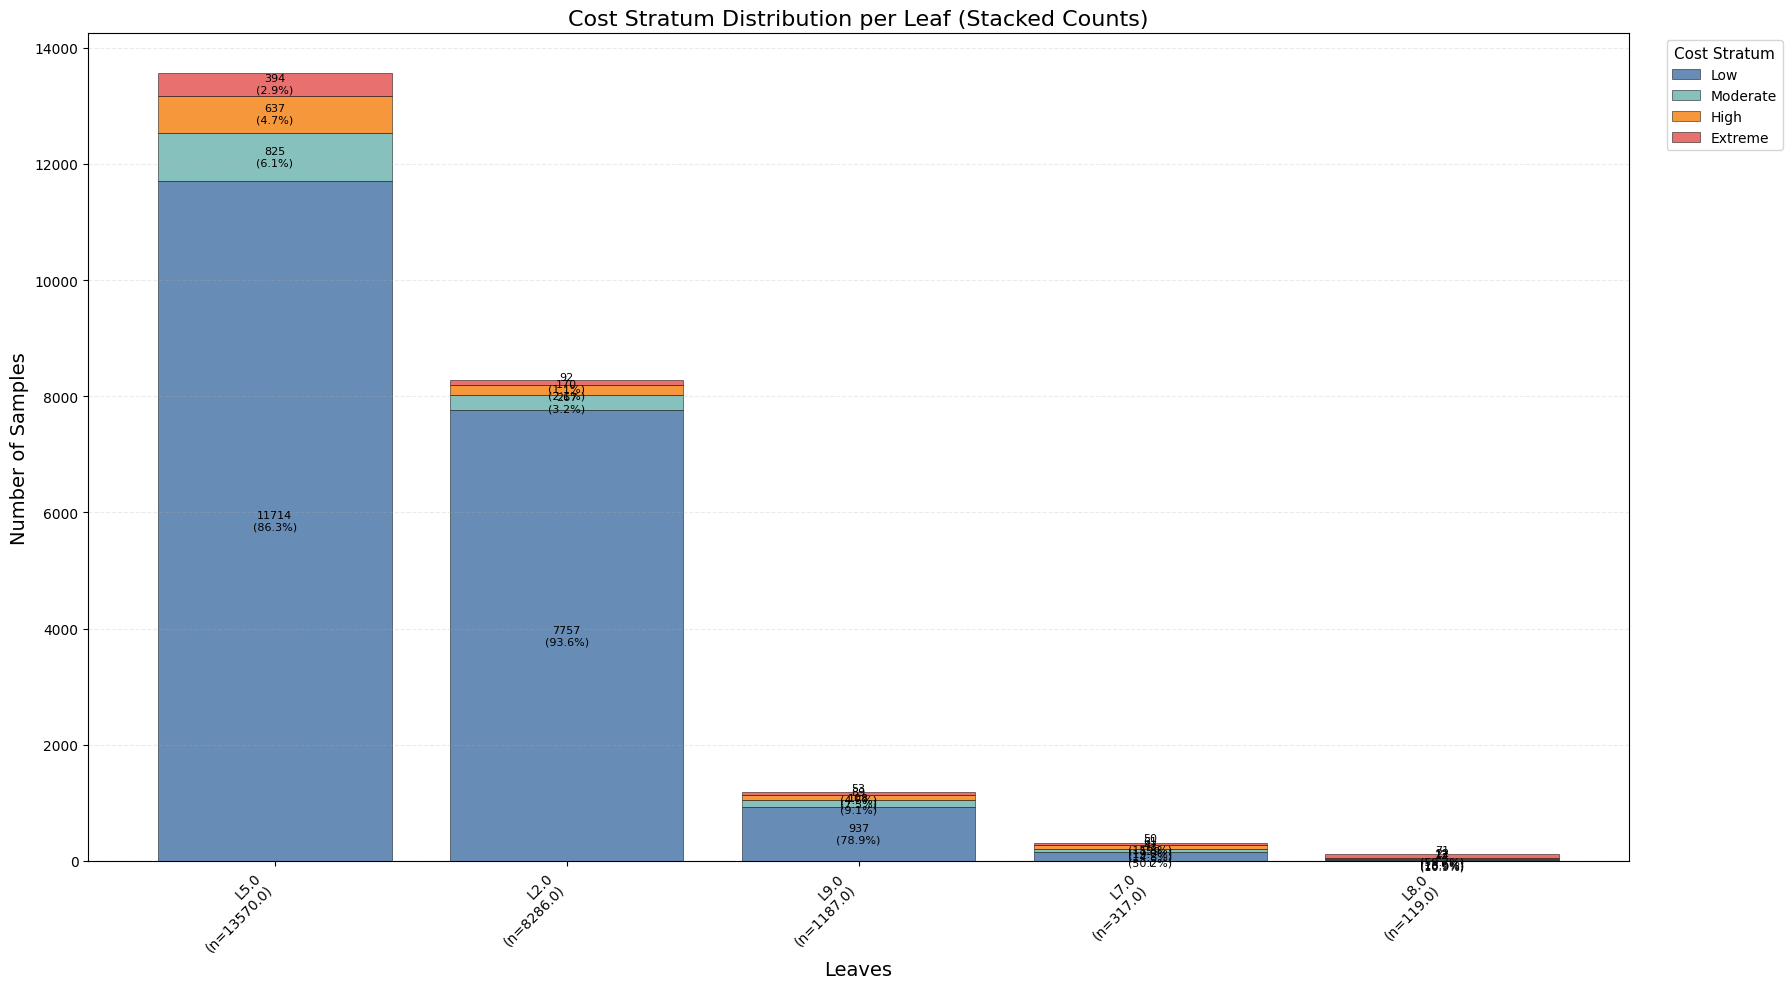


LEAF STRATUM SUMMARY
Overall class distribution across all leaves:
  Stratum 0 (Low): 20580 (87.7%)
  Stratum 1 (Moderate): 1260 (5.4%)
  Stratum 2 (High): 979 (4.2%)
  Stratum 3 (Extreme): 660 (2.8%)

Dominant stratum frequency among selected leaves:
  Stratum 0 (Low): 4 leaves (80.0%)
  Stratum 3 (Extreme): 1 leaves (20.0%)

Mean predicted vs actual rates (overall):
 Stratum    Label  Actual_Rate  Pred_Rate
       0      Low        0.877      0.995
       1 Moderate        0.054      0.005
       2     High        0.042      0.000
       3  Extreme        0.028      0.000


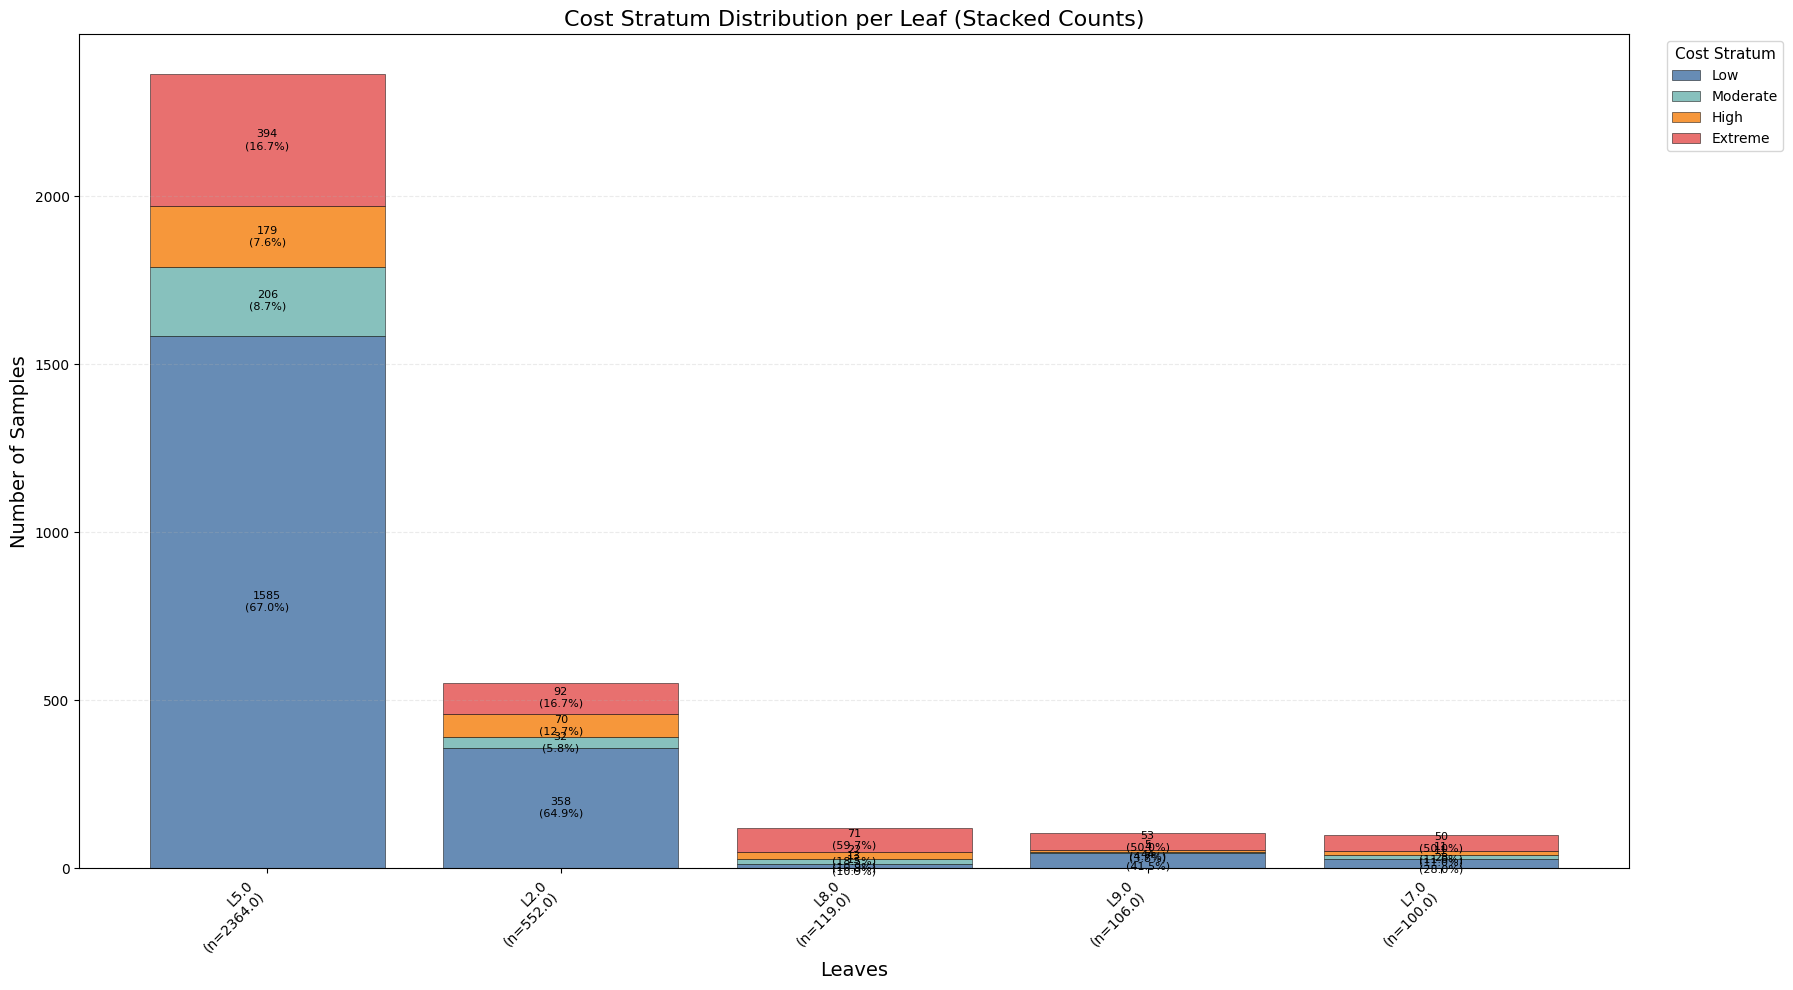


LEAF STRATUM SUMMARY
Overall class distribution across all leaves:
  Stratum 0 (Low): 2028 (62.6%)
  Stratum 1 (Moderate): 266 (8.2%)
  Stratum 2 (High): 287 (8.9%)
  Stratum 3 (Extreme): 660 (20.4%)

Dominant stratum frequency among selected leaves:
  Stratum 3 (Extreme): 3 leaves (60.0%)
  Stratum 0 (Low): 2 leaves (40.0%)

Mean predicted vs actual rates (overall):
 Stratum    Label  Actual_Rate  Pred_Rate
       0      Low        0.626      0.963
       1 Moderate        0.082      0.037
       2     High        0.089      0.000
       3  Extreme        0.204      0.000


In [ ]:
import oct_leaf_analysis
importlib.reload(oct_leaf_analysis)
labels = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
colors = {0: '#4C78A8', 1: '#72B7B2', 2: '#F58518', 3: '#E45756'}
leaf_stats_df = oct_leaf_analysis.visualize_leaf_cost_distributions_4class(
    df_M1,
    strata_labels=labels,
    strata_colors=colors
)

leaf_stats_df = oct_leaf_analysis.visualize_leaf_cost_distributions_4class(
    undersampled_training_data,
    strata_labels=labels,
    strata_colors=colors
)


# Model Comparisons

In [28]:
results_dir = "./w_sweep_results_pushpull_ratio2/" #allmajority
w_values = np.linspace(0.0, 1.0, 11)

for w in w_values:
    save_path = f"{results_dir}/undersampled_w_{w:.2f}.csv"
    undersampled_training_data = pd.read_csv(save_path)
    print("Final shape at w",w, " ",undersampled_training_data.shape)
    print(undersampled_training_data["cost_stratum_2018"].value_counts())


Final shape at w 0.0   (1980, 96)
cost_stratum_2018
0    1253
3     660
1      45
2      22
Name: count, dtype: int64
Final shape at w 0.1   (1980, 96)
cost_stratum_2018
0    1242
3     660
1      51
2      27
Name: count, dtype: int64
Final shape at w 0.2   (1980, 96)
cost_stratum_2018
0    1231
3     660
1      60
2      29
Name: count, dtype: int64
Final shape at w 0.30000000000000004   (1980, 96)
cost_stratum_2018
0    1222
3     660
1      63
2      35
Name: count, dtype: int64
Final shape at w 0.4   (1980, 96)
cost_stratum_2018
0    1217
3     660
1      65
2      38
Name: count, dtype: int64
Final shape at w 0.5   (1980, 96)
cost_stratum_2018
0    1213
3     660
1      66
2      41
Name: count, dtype: int64
Final shape at w 0.6000000000000001   (1980, 96)
cost_stratum_2018
0    1208
3     660
1      68
2      44
Name: count, dtype: int64
Final shape at w 0.7000000000000001   (1980, 96)
cost_stratum_2018
0    1205
3     660
1      70
2      45
Name: count, dtype: int64
Final shap

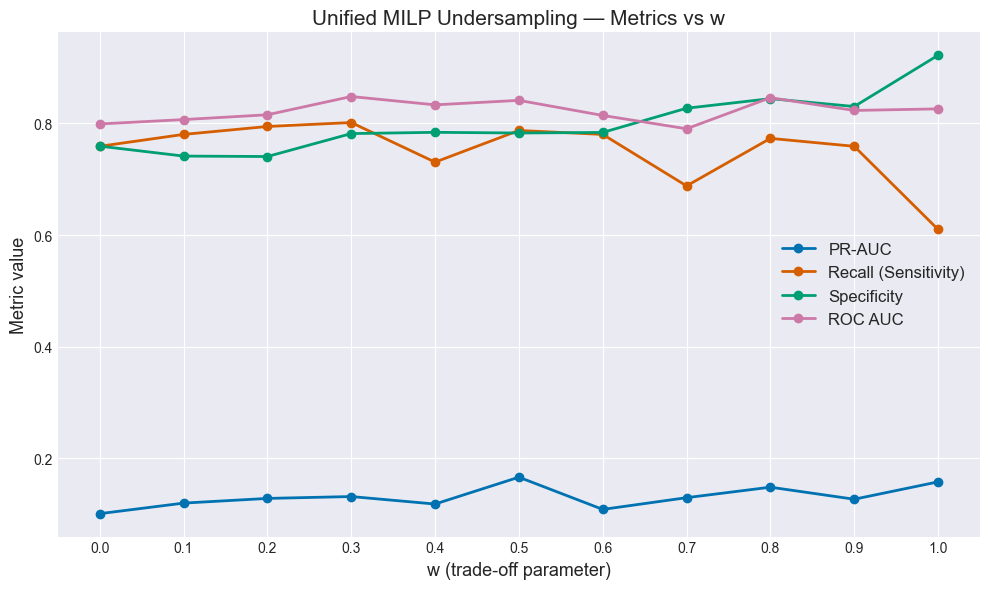

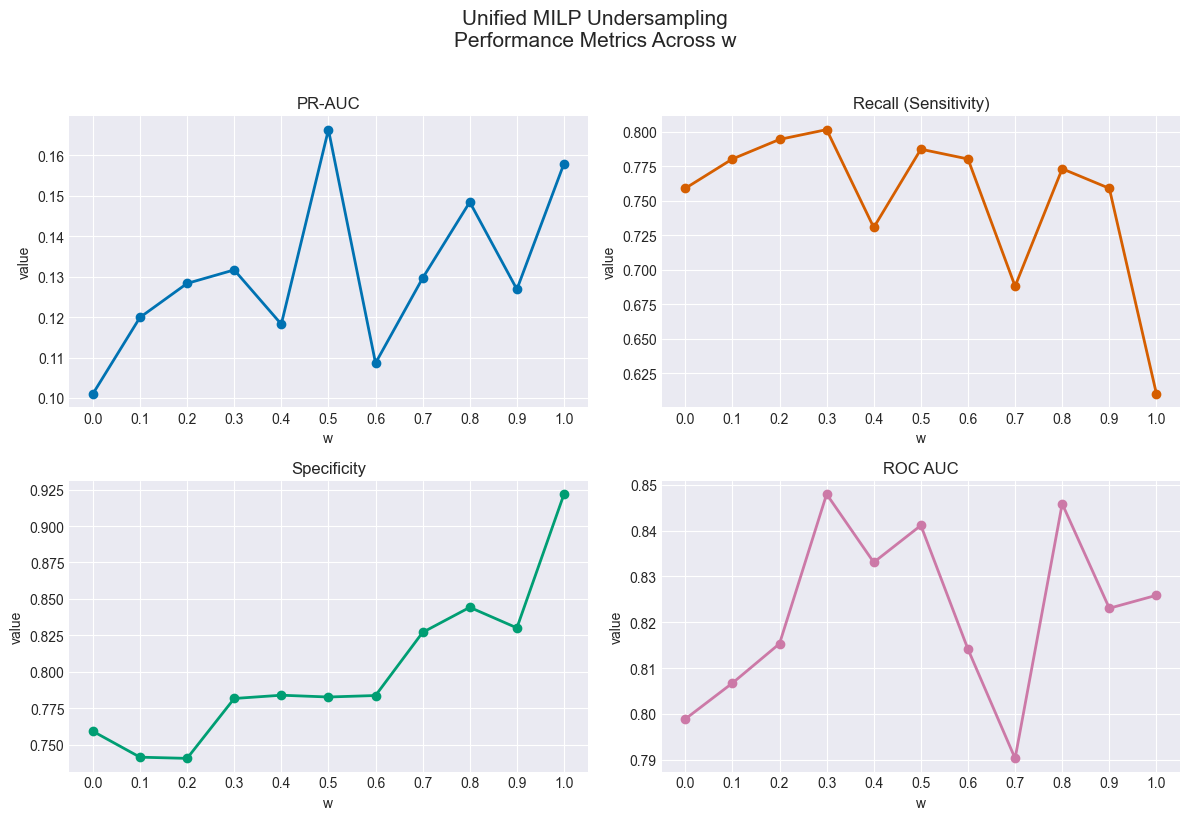

In [29]:
import re,os
import pickle

results_dir = "./w_sweep_results_pushpull_ratio2/"
#results_dir = "./w_sweep_results_dispersion/"
# Regex to extract w value from filename "metrics_full_w_0.25.pkl"
pattern = re.compile(r"metrics_full_w_([0-9.]+)\.pkl")

records = []

# Load all pickle metric files
for fname in os.listdir(results_dir):
    m = pattern.match(fname)
    if not m:
        continue

    w = float(m.group(1))
    path = os.path.join(results_dir, fname)

    with open(path, "rb") as f:
        metrics = pickle.load(f)

    metrics = metrics.copy()      # avoid mutating original dict
    metrics["w"] = w

    # Remove leaf_metrics (big dataframe)
    if "leaf_metrics" in metrics:
        del metrics["leaf_metrics"]

    records.append(metrics)

# Create DataFrame sorted by w
df = pd.DataFrame(records).sort_values("w").reset_index(drop=True)
plt.style.use("seaborn-v0_8-darkgrid")

metrics_to_plot = ["pr_auc", "sensitivity", "specificity", "auc"]
titles = ["PR-AUC", "Recall (Sensitivity)", "Specificity", "ROC AUC"]
colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

# ---------------------------
# Combined plot
# ---------------------------
plt.figure(figsize=(10, 6))
for metric, title, c in zip(metrics_to_plot, titles, colors):
    plt.plot(df["w"], df[metric], marker="o", linewidth=2, label=title, color=c)

plt.xlabel("w (trade-off parameter)", fontsize=13)
plt.ylabel("Metric value", fontsize=13)
plt.title("Unified MILP Undersampling — Metrics vs w", fontsize=15)
plt.legend(fontsize=12)
plt.xticks(df["w"])
plt.tight_layout()
plt.show()



# ---------------------------
# Separate subplot grid
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, metric, title, c in zip(axes, metrics_to_plot, titles, colors):
    ax.plot(df["w"], df[metric], marker="o", color=c, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("w")
    ax.set_ylabel("value")
    ax.set_xticks(df["w"])
    ax.grid(True)

fig.suptitle("Unified MILP Undersampling\nPerformance Metrics Across w", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


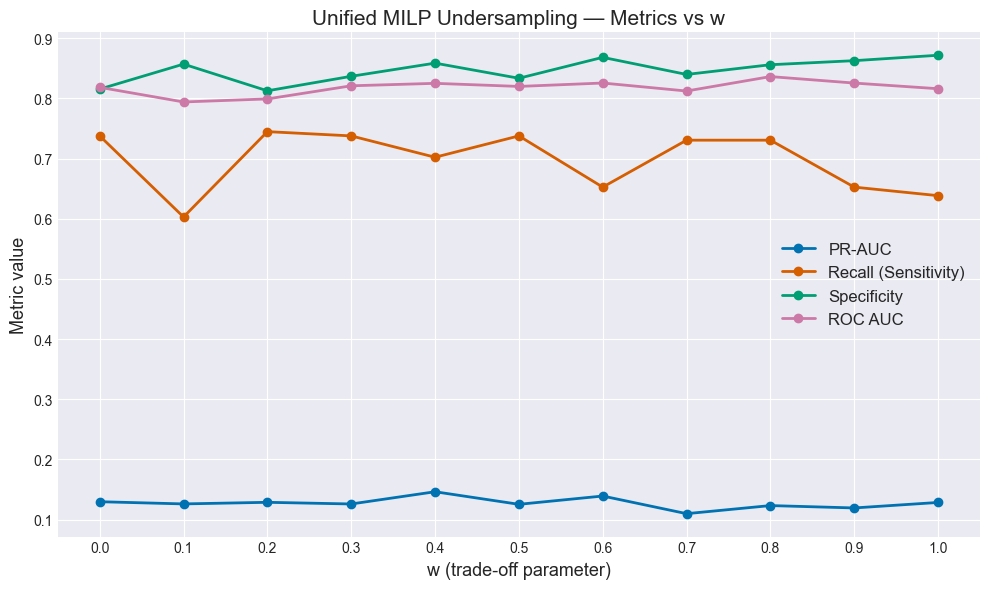

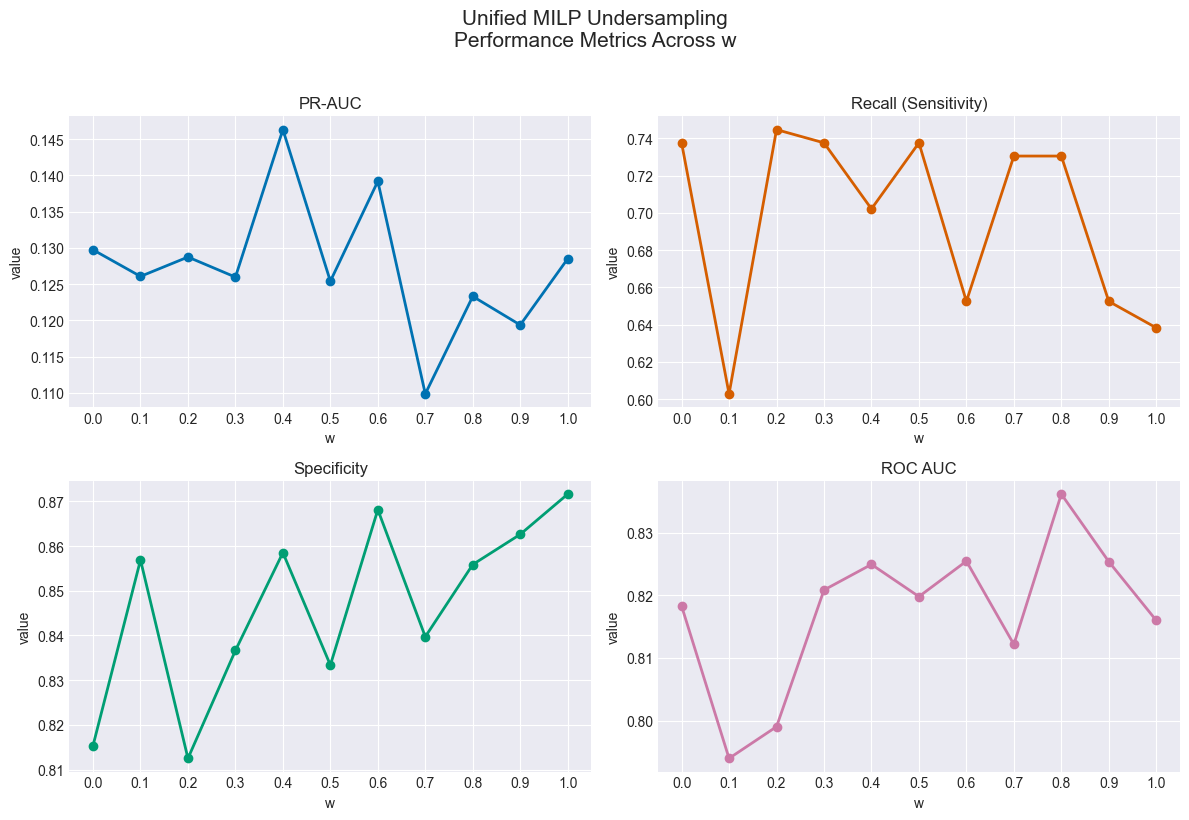

In [27]:
undersampled_training_data =  pd.read_csv(f"experiments_1016/prebalanced_matched_ratio_1.csv")


In [ ]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct

X_train_undersampled = undersampled_training_data[feature_cols]
y_train_undersampled = undersampled_training_data[target_col]
print(X_train_undersampled.shape)

minbuckets_M2=[50,100,120,150]
cps_M2=[0.00001,5e-5, 0.0001,5e-3]
depths_M2=[5,7]
balanced_model, balanced_params, results_balanced ,preprocessor, feature_names = finetune_oct(
    X_train_undersampled, y_train_undersampled,X_val, y_val,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

print("Best params:", balanced_params)
print("Balanced model: ", evaluate_binary_oct(balanced_model,X_test,y_test,preprocessor,feature_names))
balanced_model


(1244, 78)
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', 'quarterly_max_2017', 'quart

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Best params: (7, 120, 1e-05)
Test dataset for OCT application: 5,032 samples
✓ Feature names: ['INCOME_LEVEL_1', 'INCOME_LEVEL_2', 'INCOME_LEVEL_3', 'AGEGRP_2', 'AGEGRP_3', 'AGEGRP_4', 'AGEGRP_5', 'SEX_2', 'REGION_2', 'REGION_3', 'REGION_4', 'REGION_5', 'cost_pattern_2017_early_heavy', 'cost_pattern_2017_late_heavy', 'cost_stability_2017_moderate', 'cost_stability_2017_stable', 'lab_monitoring_intensity_Low', 'lab_monitoring_intensity_Minimal', 'lab_monitoring_intensity_Moderate', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Cost stratum test predictions completed
AUC score: 0.739
Sensitivity (Recall): 0.567
Specificity: 0.743
Confusion Matrix:
 [[3635 1256]
 [  61   80]]
PR-AUC (Average Precision): 0.095
Per-leaf metrics (top 10 by F1):
   leaf_id     n  accuracy  precision  recall        f1
5       13   107  0.214953   0.214953     1.0  0.353846
4       12   105  0.200000   0.200000     1.0  0.333333
7       15   101  0.128713   0.128713     1.0  0.228070
6       14   104  0.125000   0.125000     1.0  0.222222
1        8   919  0.010881   0.010881     1.0  0.021529
0        5  2362  0.989416   0.000000     0.0  0.000000
2        9  1141  0.978089   0.000000     0.0  0.000000
3       11   193  0.943005   0.000000     0.0  0.000000
Balanced model:  None


[ Warning: The type of y (Any) does not match the original target type (Int64)


Fitted OptimalTreeClassifier:
  1) Split: ckd_cost_deriv_Q2_Q3_2017 < 0.46
    2) Split: 2017Q1_ckd_cost < 0.4374
      3) Split: quarterly_max_2017 < 0.1005
        4) Split: Analg/Antipyr, Opiate Agonists (THRCLS_60) < 0.5
          5) Predict: 0 (64.00%), [112,63], 175 points, error 0.36
          6) Split: 2017Q4_direct_ckd_cost < -0.3166
            7) Split: 2017Q3_ckd_claims < -0.609
              8) Predict: 1 (57.42%), [66,89], 155 points, error 0.4258
              9) Predict: 0 (61.51%), [179,112], 291 points, error 0.3849
            10) Split: total_lab_tests < -0.1731
              11) Predict: 0 (61.42%), [78,49], 127 points, error 0.3858
              12) Predict: 1 (67.50%), [39,81], 120 points, error 0.325
        13) Predict: 1 (64.23%), [44,79], 123 points, error 0.3577
      14) Predict: 1 (71.54%), [35,88], 123 points, error 0.2846
    15) Predict: 1 (76.15%), [31,99], 130 points, error 0.2385

In [23]:
# Logistic Regression for binary high-cost prediction
from model_pipeline import evaluate_model_auc
print("Training Logistic Regression model...")
log_pipeline = model_pipeline.get_logistic_pipeline(
    df=X_train_undersampled,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, C=0.1, max_iter=1000,
)
log_pipeline.fit(X_train_undersampled, y_train_undersampled)  # Binary classification
evaluate_model_auc(log_pipeline, X_test, y_test, optimal_threshold=True)

# Random Forest for binary high-cost prediction
print("Training Random Forest model...")
rf_pipeline = model_pipeline.get_random_forest_pipeline(
    df=X_train_undersampled ,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, 
)
rf_pipeline.fit(X_train_undersampled, y_train_undersampled )  # Binary classification
evaluate_model_auc(rf_pipeline, X_test, y_test, optimal_threshold=True)

# Gradient Boosting for binary high-cost prediction
print("Training Gradient Boosting model...")
gb_pipeline = model_pipeline.get_histgb_pipeline(
   df=X_train_undersampled ,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, balance_classes = True
)
gb_pipeline.fit(X_train_undersampled, y_train_undersampled)  # Binary classification
evaluate_model_auc(gb_pipeline, X_test, y_test, optimal_threshold=True)

Training Logistic Regression model...
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', '

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
X = train_pd.drop(columns=[target_col])
y = train_pd[target_col]

ratio = 2.0   # majority should be 2x minority

minority_count = y.value_counts()[1]
target_majority = int(minority_count * ratio)

rus = RandomUnderSampler(
    sampling_strategy={0: target_majority, 1: minority_count},
    random_state=42
)

X_res, y_res = rus.fit_resample(X, y)

undersampled_rus = pd.concat([X_res, y_res], axis=1)
print(undersampled_rus['cost_stratum_2018'].value_counts())

print(X_res.shape)
rus_model, rus_params, results_rus,preprocessor, feature_names = finetune_oct(
    X_res[feature_cols], y_res,X_val, y_val,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,
    depths=depths_M2,
    minbuckets=minbuckets_M2,
    cps=cps_M2
)

print("Best params:", rus_params)
print(results_rus)
rus_model


evaluate_binary_oct(rus_model,X_test,y_test,preprocessor,feature_names)

cost_stratum_2018
0    1186
3     660
1      79
2      55
Name: count, dtype: int64
(1980, 95)
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness